# Exp 2 — Deterministic rules baseline (V2, semantic edition)
**Question:** how much of expense compliance can ordinary code solve, with no AI, once every decision-critical fact lives in free text instead of a structured form?

**Systems (no LLM, cost $0):**
- **2a, as-is:** `src/rules.py`, the earliest rules (constants mostly from the V1 policy), unchanged.
- **2b, frozen V2 rules:** `src/rules_v2.py`, written from the V2 policy text and tuned on the *easy* V2 (100% there, 30/30 on its validation split). Frozen: not touched for this run. It reads structured form fields, which no longer exist, so wherever a field is missing it falls back to defaults or crashes (a crash is scored as ESCALATE).
- **2c, rules + regex text parsing:** `src/rules_text.py` rebuilds the structured facts from the note with regular expressions (number words, dates, keywords) and then calls the frozen 2b logic. This is the strongest deterministic baseline: it tells us how much of the new difficulty is only "parsing".

**Data:** 70 development claims for the main comparison, then the same three systems on the 30 unseen validation claims. Final test untouched.
**Honesty note on 2c:** its patterns were written after reading development notes, so its dev score is optimistic; validation is the fair number. Nothing here is tuned on validation.

In [1]:
import json, sys, time, uuid
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, rules, rules_v2, rules_text, evaluate, metrics_ext
pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP02_RULES'; OUT = C.RESULTS/'development'/'exp02_rules'; OUT.mkdir(parents=True, exist_ok=True)
gt = evaluate.load_gt()
def load(split): return [json.loads(l) for l in (C.CASES/f'{split.lower()}.jsonl').read_text().splitlines() if l.strip()]
def run(name, fn, split):
    recs = []; run_id = f'{EXP}-{name}-{split}-{uuid.uuid4().hex[:6]}'; crashes = 0
    for c in load(split):
        t0 = time.perf_counter()
        try: d = fn(c); err = None
        except Exception as e: d = {'decision':'ESCALATE','policy_evidence':[],'missing_fields':[],'reason':'crash','manual_review_required':True}; err = repr(e)[:150]; crashes += 1
        ms = (time.perf_counter()-t0)*1000
        r = {'case_id':c['case_id'],'predicted_decision':d['decision'],'policy_evidence':d['policy_evidence'],'missing_fields':d['missing_fields'],'reason':d.get('reason'),
             'manual_review_required':d['manual_review_required'],'latency_ms':round(ms,3),'input_tokens':0,'output_tokens':0,'model_cost_usd':0.0,'error':err}
        recs.append(r)
        llm.log_event(type='case_result', run_id=run_id, experiment=EXP, split=split, model=name, **{k:v for k,v in r.items() if k!='case_id'}, case_id=c['case_id'])
    summary, rows = evaluate.evaluate(recs, gt); ext = metrics_ext.extended(recs, gt); summary['crashes_scored_as_escalate'] = crashes
    llm.log_event(type='experiment_summary', run_id=run_id, experiment=EXP, split=split, model=name, config={'rules': name, 'dataset': 'semantic'}, **summary)
    tag = f'{name}_{split.lower()}'
    (OUT/f'predictions_{tag}.jsonl').write_text('\n'.join(json.dumps(r) for r in recs)+'\n'); (OUT/f'evaluation_{tag}.jsonl').write_text('\n'.join(json.dumps(r) for r in rows)+'\n')
    (OUT/f'summary_{tag}.json').write_text(json.dumps({'run_id':run_id, **summary, 'extended':ext}, indent=1, default=str))
    return summary, recs, rows, ext
SYS = {'2a as-is': rules.decide, '2b frozen V2 rules': rules_v2.decide, '2c rules + regex parsing': rules_text.decide}
dev = {k: run(k.split()[0]+'_'+('asis' if k.startswith('2a') else 'frozen' if k.startswith('2b') else 'regex'), fn, 'DEVELOPMENT') for k, fn in SYS.items()}
print({k:(v[0]['correct'], v[0]['n']) for k, v in dev.items()})

{'2a as-is': (23, 70), '2b frozen V2 rules': (35, 70), '2c rules + regex parsing': (65, 70)}


## Comparison table, development (70 claims): standard metrics

In [2]:
def row(k, s): return {'system':k, 'correct/N':f"{s['correct']}/{s['n']}", 'CDR':s['correct_disposition_rate'], 'Wilson95':s['wilson95'], 'false_approvals':f"{s['false_approvals']}/{s['non_approvable']}",
        'FAR':s['false_approval_rate'], 'human_review_rate':s['human_review_rate'], 'crashes':s['crashes_scored_as_escalate'], 'median_ms':s['median_latency_ms'], 'p95_ms':s['p95_latency_ms'], 'cost_usd':s['total_cost_usd']}
pd.DataFrame([row(k, v[0]) for k, v in dev.items()])

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,crashes,median_ms,p95_ms,cost_usd
0,2a as-is,23/70,0.3286,"(0.23, 0.445)",18/52,0.3462,0.2857,0,0.0970,0.273,0.0
1,2b frozen V2 rules,35/70,0.5000,"(0.386, 0.614)",14/52,0.2692,0.4857,5,1.4285,1.605,0.0
2,2c rules + regex parsing,65/70,0.9286,"(0.8434, 0.9691)",0/52,0.0000,0.2143,0,1.3530,2.014,0.0


## Extended metrics (macro-F1, wrongful rejection, escalation errors, error among auto-resolved, citation, missing-field P/R)

In [3]:
pd.DataFrame([{'system':k, **metrics_ext.table(v[3])} for k, v in dev.items()])

,system,macro_F1,wrongful_reject,over_escal_rate,missed_escal_rate,err_among_auto,cite_prec,cite_rec,mf_prec,mf_rec,cost/correct
0,2a as-is,0.3152,2/18,0.1857,0.5882,0.6800,0.1047,0.0381,0.118,0.125,0.0
1,2b frozen V2 rules,0.4587,0/18,0.2571,0.0588,0.4722,0.4500,0.1148,0.571,0.250,0.0
2,2c rules + regex parsing,0.9287,1/18,0.0000,0.1176,0.0909,0.8333,0.2984,0.500,0.688,0.0


In [4]:
for k, v in dev.items():
    print(k); print(pd.DataFrame(v[3]['per_class']).T.round(3).to_string(), '\n')

2a as-is
                     support  precision  recall     f1
APPROVE                 18.0      0.333   0.500  0.400
REJECT                  19.0      0.500   0.158  0.240
REQUEST_INFORMATION     16.0      0.235   0.250  0.242
ESCALATE                17.0      0.350   0.412  0.378 

2b frozen V2 rules
                     support  precision  recall     f1
APPROVE                 18.0      0.440   0.611  0.512
REJECT                  19.0      1.000   0.211  0.348
REQUEST_INFORMATION     16.0      0.571   0.250  0.348
ESCALATE                17.0      0.471   0.941  0.627 

2c rules + regex parsing
                     support  precision  recall     f1
APPROVE                 18.0      1.000   0.889  0.941
REJECT                  19.0      0.947   0.947  0.947
REQUEST_INFORMATION     16.0      0.800   1.000  0.889
ESCALATE                17.0      1.000   0.882  0.938 



## Where the systems succeed and fail (development)

In [5]:
def fam_table(k):
    d = pd.DataFrame(dev[k][2]); return d.groupby('case_family').correct.agg(['sum','count']).rename(columns={'sum':k.split()[0]+' ok','count':'n'})
fam = fam_table('2a as-is').join(fam_table('2b frozen V2 rules').drop(columns='n')).join(fam_table('2c rules + regex parsing').drop(columns='n'))
fam['group'] = pd.DataFrame(dev['2a as-is'][2]).groupby('case_family').architecture_group.first(); print(fam.sort_values('n', ascending=False).to_string())
grp = pd.concat({k.split()[0]: pd.DataFrame(v[2]).groupby('architecture_group').correct.agg(['sum','count']) for k, v in dev.items()}, axis=1); print(); print(grp)

                              2a ok  n  2b ok  2c ok             group
case_family                                                           
HOTEL_CEILING                     0  7      0      7        B_WORKFLOW
DYNAMIC_HOTEL_DISCOVERY           4  5      4      5   C_AGENT_DYNAMIC
APPROVAL_TIERS                    1  5      5      5        B_WORKFLOW
DYNAMIC_DELEGATION_CHAIN          1  5      5      3   C_AGENT_DYNAMIC
TRAINING_CAP                      3  4      3      4        B_WORKFLOW
SPLIT_TRANSACTION                 0  4      1      4        B_WORKFLOW
HOTEL_EXCEPTION                   1  3      1      3        B_WORKFLOW
GIFT_ANNUAL_CAP                   2  3      2      3        B_WORKFLOW
EMPLOYEE_MEAL_TEMPORAL            1  3      1      3  A_SELF_CONTAINED
AIRFARE_CABIN                     0  3      0      2        B_WORKFLOW
DUPLICATE_CHECK                   3  3      2      3        B_WORKFLOW
SUBMISSION_WINDOW                 2  2      2      2  A_SELF_CONTAINED
ALCOHO

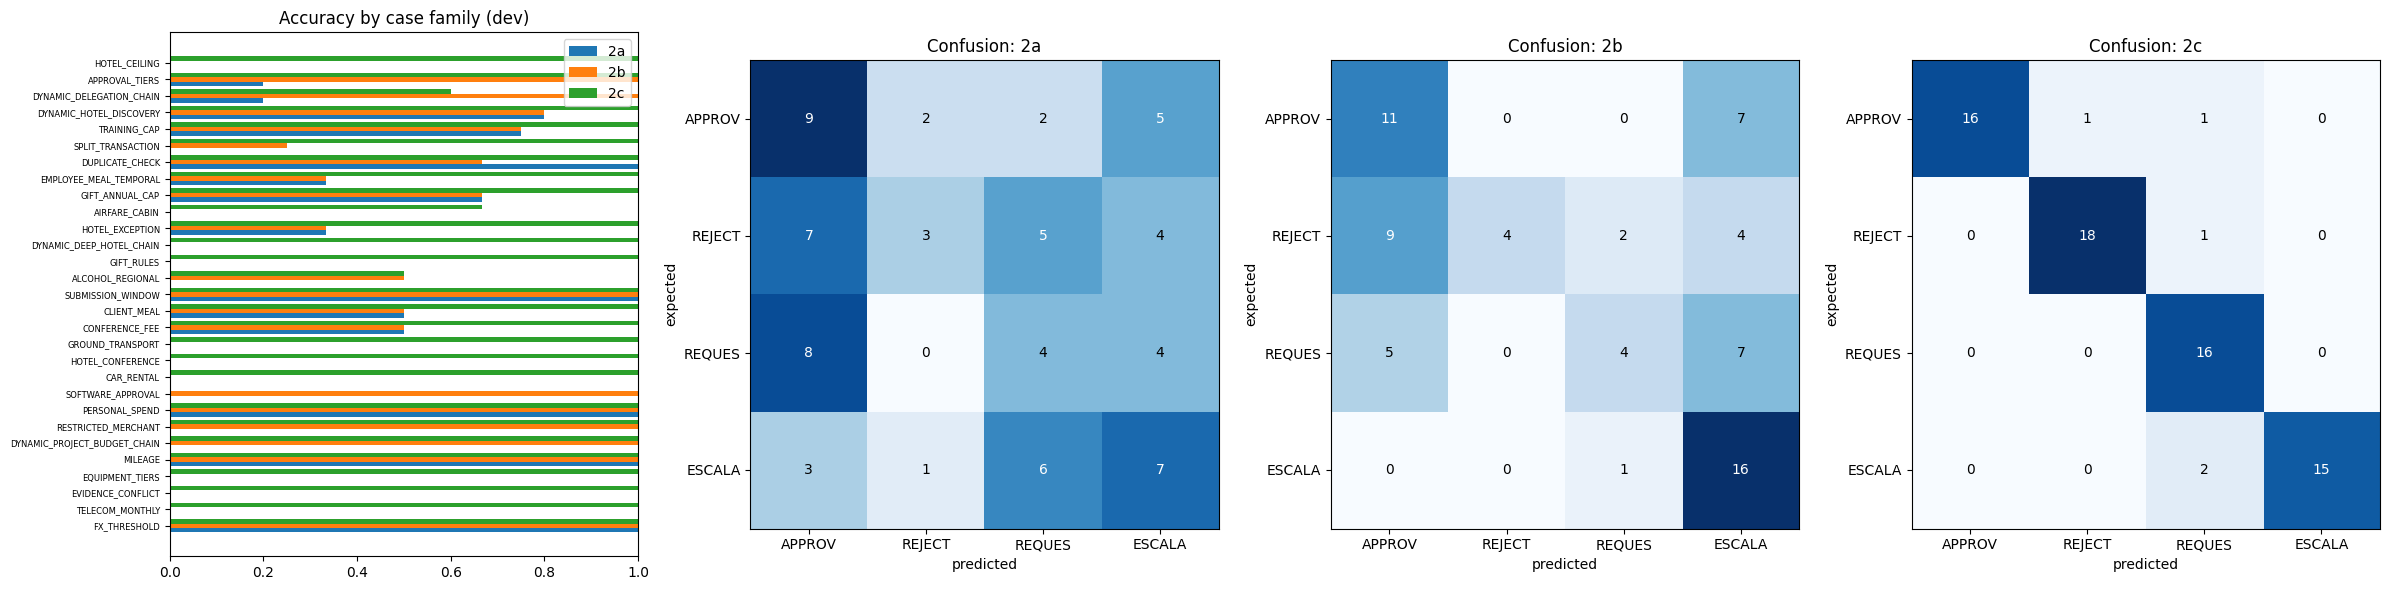

In [6]:
D = ['APPROVE','REJECT','REQUEST_INFORMATION','ESCALATE']
fig, ax = plt.subplots(1, 4, figsize=(24, 6))
f2 = fam.sort_values('n'); h = .27; y = np.arange(len(f2))
for j, col in enumerate(['2a ok','2b ok','2c ok']): ax[0].barh(y + (j-1)*h, f2[col]/f2.n, height=h, label=col[:2])
ax[0].set_yticks(y); ax[0].set_yticklabels(f2.index, fontsize=6); ax[0].set_xlim(0,1); ax[0].legend(); ax[0].set_title('Accuracy by case family (dev)')
for a, k in zip(ax[1:], dev):
    m = pd.crosstab(pd.Categorical([r['expected_decision'] for r in dev[k][2]], D), pd.Categorical([r['predicted_decision'] for r in dev[k][2]], D), dropna=False).values
    a.imshow(m, cmap='Blues'); a.set_xticks(range(4)); a.set_yticks(range(4)); a.set_xticklabels([d[:6] for d in D]); a.set_yticklabels([d[:6] for d in D]); a.set_xlabel('predicted'); a.set_ylabel('expected'); a.set_title('Confusion: '+k.split()[0])
    for i in range(4):
        for j in range(4): a.text(j, i, m[i,j], ha='center', va='center', color='w' if m[i,j] > m.max()/2 else 'k')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp02_rules_development.png', dpi=130); plt.show()

## Failure analysis

In [7]:
kinds = {}
for k in dev:
    d = pd.DataFrame(dev[k][2]); bad = d[~d.correct]
    kinds[k.split()[0]] = {'failures': len(bad), 'false approvals': int((bad.predicted_decision=='APPROVE').sum()), 'wrongful rejections': int((bad.predicted_decision=='REJECT').sum()), 'wrong review/escalation route': int(bad.predicted_decision.isin(['REQUEST_INFORMATION','ESCALATE']).sum())}
print(pd.DataFrame(kinds).to_string())
d = pd.DataFrame(dev['2c rules + regex parsing'][2]); r = {x['case_id']:x['reason'] for x in dev['2c rules + regex parsing'][1]}; d['reason'] = d.case_id.map(r)
notes = {c['case_id']: c['employee_description'] for c in load('DEVELOPMENT')}; d['note'] = d.case_id.map(notes).str[:170]
print('\n2c failures on dev:'); d[~d.correct][['case_id','case_family','expected_decision','predicted_decision','reason','note']]

                               2a  2b  2c
failures                       47  35   5
false approvals                18  14   0
wrongful rejections             3   0   1
wrong review/escalation route  26  21   4

2c failures on dev:


,case_id,case_family,expected_decision,predicted_decision,reason,note
21,X2-047,DYNAMIC_DELEGATION_CHAIN,APPROVE,REQUEST_INFORMATION,Attendee count needed.,"Hosted meal for Ember Foods delegates at Raffles Grill, SGD. Pax: me, 8 colleagues, 9 delegates ..."
23,X2-049,ALCOHOL_REGIONAL,REJECT,REQUEST_INFORMATION,Attendee count needed.,"Please find the receipt for a meal hosted for external guests at Lotus Kitchen in Mumbai, India...."
25,X2-055,DYNAMIC_DELEGATION_CHAIN,APPROVE,REJECT,Per-person spend 180 exceeds ceiling 120.,We had a productive team dinner at Telok Ayer Terrace with delegates from Halcyon Freight to dis...
26,X2-059,SOFTWARE_APPROVAL,ESCALATE,REQUEST_INFORMATION,Named business owner required.,"We had our regular monthly review for the research group, where we discussed ongoing projects an..."
35,X2-080,AIRFARE_CABIN,ESCALATE,REQUEST_INFORMATION,Description conflicts with the bill category.,I booked an airfare with Merlion Air for our upcoming regional planning offsite. The ticket was ...


## Generalization check: all three systems on the 30 unseen validation claims
Nothing was tuned on these. Run once.

In [8]:
val = {k: run(k.split()[0]+'_'+('asis' if k.startswith('2a') else 'frozen' if k.startswith('2b') else 'regex'), fn, 'VALIDATION') for k, fn in SYS.items()}
pd.DataFrame([row(k, v[0]) for k, v in val.items()]).join(pd.DataFrame([metrics_ext.table(v[3]) for v in val.values()]))

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,crashes,median_ms,p95_ms,cost_usd,macro_F1,wrongful_reject,over_escal_rate,missed_escal_rate,err_among_auto,cite_prec,cite_rec,mf_prec,mf_rec,cost/correct
0,2a as-is,8/30,0.2667,"(0.1418, 0.4445)",8/22,0.3636,0.3667,0,0.095,0.118,0.0,0.2614,0/8,0.3,0.7143,0.6842,0.1316,0.0750,0.167,0.143,0.0
1,2b frozen V2 rules,14/30,0.4667,"(0.3023, 0.6386)",4/22,0.1818,0.6333,4,1.439,1.510,0.0,0.4402,0/8,0.4,0.0000,0.3636,0.3158,0.1050,0.667,0.286,0.0
2,2c rules + regex parsing,25/30,0.8333,"(0.6644, 0.9266)",1/22,0.0455,0.2000,0,1.379,1.524,0.0,0.8367,1/8,0.0,0.1429,0.2083,0.7391,0.2167,0.600,0.857,0.0


In [9]:
print(pd.concat({k.split()[0]: pd.DataFrame(v[2]).groupby('architecture_group').correct.agg(['sum','count']) for k, v in val.items()}, axis=1))
both = pd.DataFrame([{'system':k.split()[0], 'dev':f"{dev[k][0]['correct']}/70", 'validation':f"{val[k][0]['correct']}/30", 'dev CDR':dev[k][0]['correct_disposition_rate'], 'val CDR':val[k][0]['correct_disposition_rate'], 'val Wilson95':val[k][0]['wilson95']} for k in dev]); both

                    2a        2b        2c      
                   sum count sum count sum count
architecture_group                              
A_SELF_CONTAINED     4     8   6     8   4     8
B_WORKFLOW           2    16   5    16  16    16
C_AGENT_DYNAMIC      2     6   3     6   5     6


,system,dev,validation,dev CDR,val CDR,val Wilson95
0,2a,23/70,8/30,0.3286,0.2667,"(0.1418, 0.4445)"
1,2b,35/70,14/30,0.5000,0.4667,"(0.3023, 0.6386)"
2,2c,65/70,25/30,0.9286,0.8333,"(0.6644, 0.9266)"


## Before vs after the semantic rebuild (same rule code, easy V2 vs semantic V2)
The easy-V2 numbers below come from the archived Exp 2 run (`results/v2_easy_archive/`), read from its saved summary files, not retyped.

In [10]:
arch = C.RESULTS.parent/'v2_easy_archive'/'development'/'exp02_rules'
def old(tag, split): 
    p = arch/f'summary_{tag}_{split}.json'; 
    if p.exists(): s = json.loads(p.read_text()); return f"{s['correct']}/{s['n']}"
    return None
easy_dev = {'2a': '24/70', '2b': '70/70'}   # from docs/v2 easy-run record; summary files for the 2b-easy run are in the archive
sm = {}
for p in sorted(arch.glob('summary_*.json')): sm[p.stem] = f"{json.loads(p.read_text())['correct']}/{json.loads(p.read_text())['n']}"
print('archived easy-V2 summaries:', sm)
pd.DataFrame([{'system':k.split()[0], 'easy V2 dev':sm.get('summary_rules_2a_asis_development' if k.startswith('2a') else 'summary_rules_2b_v2_development'), 'semantic V2 dev':f"{dev[k][0]['correct']}/70"} for k in list(dev)[:2]])

archived easy-V2 summaries: {'summary_rules_2a_asis_development': '24/70', 'summary_rules_2b_v2_development': '70/70', 'summary_rules_2b_v2_validation': '30/30'}


,system,easy V2 dev,semantic V2 dev
0,2a,24/70,23/70
1,2b,70/70,35/70


## What was done and what it means
- **Same rule code, easy vs semantic data:** the frozen V2 rules (2b) scored 70/70 on dev and 30/30 on validation when the facts sat in structured form fields. On the semantic edition they score **35/70 = 50% on dev (CI 39-61%) and 14/30 = 47% on validation**, with 14 dev false approvals out of 52 non-approvable claims (27%) and 5 dev crashes on missing fields. So the rebuild does what it was meant to: a lookup over structured fields no longer works. The existing rules (2a) score 23/70 = 33% dev and 8/30 = 27% validation.
- **How much of the difficulty is only parsing?** Adding regex parsing (2c) recovers most of it: **65/70 = 93% on dev, 25/30 = 83% on validation (CI 66-93%)**, with 0 false approvals on dev and 1/22 on validation. 2c's patterns were written after reading development notes, so 83% is the fairer estimate, and with 30 claims it is uncertain.
- **Where 2c still fails:** meals. Headcounts written as a list of people ("me, 8 colleagues, 9 delegates"), an alcohol amount written in words, and one business owner named in a subordinate clause; one false conflict trigger from keyword words in an airfare note. Families that hinge on identifiers and dates (hotel, delegation chains, splits, approvals) are parsed easily because the notes state them plainly. On validation the self-contained group A is the hardest (4/8) while workflow claims parse well (16/16).
- **Effort:** the parser is about 120 lines of patterns plus the 438-line rule engine, all hand-maintained, and it is tuned to this dataset's phrasing. Different wording (another note style) would break it, which is what an LLM reader should handle better.
- **Extended metrics:** 2c has macro-F1 0.93 (dev) and 0.84 (validation); citation recall is low for all rule systems (0.30 dev) because rules cite only the clause that fired.
- **Caveats:** the notes are LLM-drafted and only automatically validated, not human-reviewed. Final test untouched. The run log holds two executions of this notebook (a re-run to fix a path in the last table); the result files were overwritten by the second one.
- **Decision:** the deterministic bar to beat is now 2c: about 83% (validation) with 1 false approval, at zero cost and about 1 ms per claim. The dataset is harder than before but still only moderately hard for a determined regex engineer. Proceed to Exp 3 (generic LLM), and consider a second hardening pass later if LLM systems also saturate.